In [7]:
from pathlib import Path
import sys
root = Path.cwd().parent
sys.path.append(str(root))

from AlphaBase import AlphaBase
alpha = AlphaBase()

# Load Data
data_list = alpha.generate_data()

# # Btc
# btc = data_list['btcusdt_10m']
# btc = btc.set_index('datetime')
# mask = (
#     (btc.index.dayofweek < 5) &
#     ((btc.index.hour <= 4) |
#     (btc.index.hour >= 20))
# )

# btc = btc.loc[mask]


# # Eth
# eth = data_list['ethusdt_10m']
# eth = eth.set_index('datetime')
# mask = (
#     (eth.index.dayofweek < 5) &
#     ((eth.index.hour <= 4) |
#     (eth.index.hour >= 20))
# )

# eth = eth.loc[mask]

# df = eth.merge(btc, on='datetime', how='left', suffixes=('', '_btc')).ffill()

# vn30f1m_15m
vnf1m = data_list['Vn30F1M_15m']
vn = data_list['vn30_15m']
vnf1m = data_list['Vn30F1M_15m']
vn = data_list['vn30_15m']

vnmerge = vnf1m.merge(
    vn,
    on='datetime',
    how='left',
    suffixes=('', '_vn30')
)

cols = ['open', 'high', 'low', 'close', 'volume']

for col in cols:
    vnmerge[f'{col}_vn30'] = vnmerge[f'{col}_vn30'].ffill()

vnmerge = vnmerge.dropna().reindex()

[WARNING] Trading View's limit on INTRADAY DATA for VN30 can cause unexpected error! 
[WARNING] Trading View's limit on INTRADAY DATA for VN30F1M can cause unexpected error! 
[CACHE] Loaded VN30F1M_15m sucessfully
[CACHE] Loaded VN30_15m sucessfully

Successfully scraped 2/2 symbol


In [2]:
# from Alpha.hmm_regime_pipeline import run_pipeline
# pipe, feat, hp, wf_result, labeled = run_pipeline(vnf1m)

In [ ]:
param_range = {
    "bb_lookback": (10, 80),
    "bb_nstd": (1.2, 3.5),
    "vol_lookback": (5, 60),
    "vol_mult": (1.0, 3.0)
}

In [4]:
# By what % we should split our data
oos_ratio = 0.9

In [5]:

alpha.train(vnmerge, param_range=param_range, opt_metric="sharpe", n_trials=30, n_fold=5, oos_ratio=oos_ratio)

[I 2026-07-23 16:00:24,205] A new study created in memory with name: no-name-9811979c-7dd8-4bf7-860c-b52274568cc5
[I 2026-07-23 16:00:24,392] Trial 0 finished with value: -1.1297448675477022 and parameters: {'vol_mult': 1.7605406320698145, 'bb_lookback': 79, 'bb_nstd': 1.8032010831176088, 'vol_lookback': 13}. Best is trial 0 with value: -1.1297448675477022.
[I 2026-07-23 16:00:24,520] Trial 1 finished with value: -1.971259006204957 and parameters: {'vol_mult': 1.6780371152460924, 'bb_lookback': 47, 'bb_nstd': 2.1081031196814752, 'vol_lookback': 18}. Best is trial 0 with value: -1.1297448675477022.
[I 2026-07-23 16:00:24,651] Trial 2 finished with value: -0.8785122104976739 and parameters: {'vol_mult': 2.643945422681541, 'bb_lookback': 77, 'bb_nstd': 1.623482241142922, 'vol_lookback': 53}. Best is trial 2 with value: -0.8785122104976739.
[I 2026-07-23 16:00:24,791] Trial 3 finished with value: -4.566265439152628 and parameters: {'vol_mult': 1.0893785316564604, 'bb_lookback': 44, 'bb_nst

AFTER OPTUNA PLEASE RUN CELL 1 AGAIN TO SEE RESULT AFTER OPTIMIZATION
##########################################  
        Financial Backtest vn_future 
##########################################
 
IN SAMPLE PERFORMANCE

             Financial Backtest Vn Future
    Initial capital: 10,000.00
     Ending capital: 10,118.25
             Sharpe: 0.57
            Sortino: 0.41
             Calmar: 0.99
                MDD: 143.30 (1.43%); Time: 2018-03-08 09:15:00 -> 2018-04-12 09:30:00
       Total Profit: 118.25
   Margin per Trade: 2.50 bps
       Total Return: 1.01%
    Return per year: 1.42%
               CAGR: 1.42%
       Hitrate Long: 0.00%
      Hitrate Short: 0.00%
      Total Hitrate: 0.00%
        Longest Win: 2 days
       Longest Loss: 3 days
      Trade per Day: 0.13
        Long Trades: 14
       Short Trades: 10



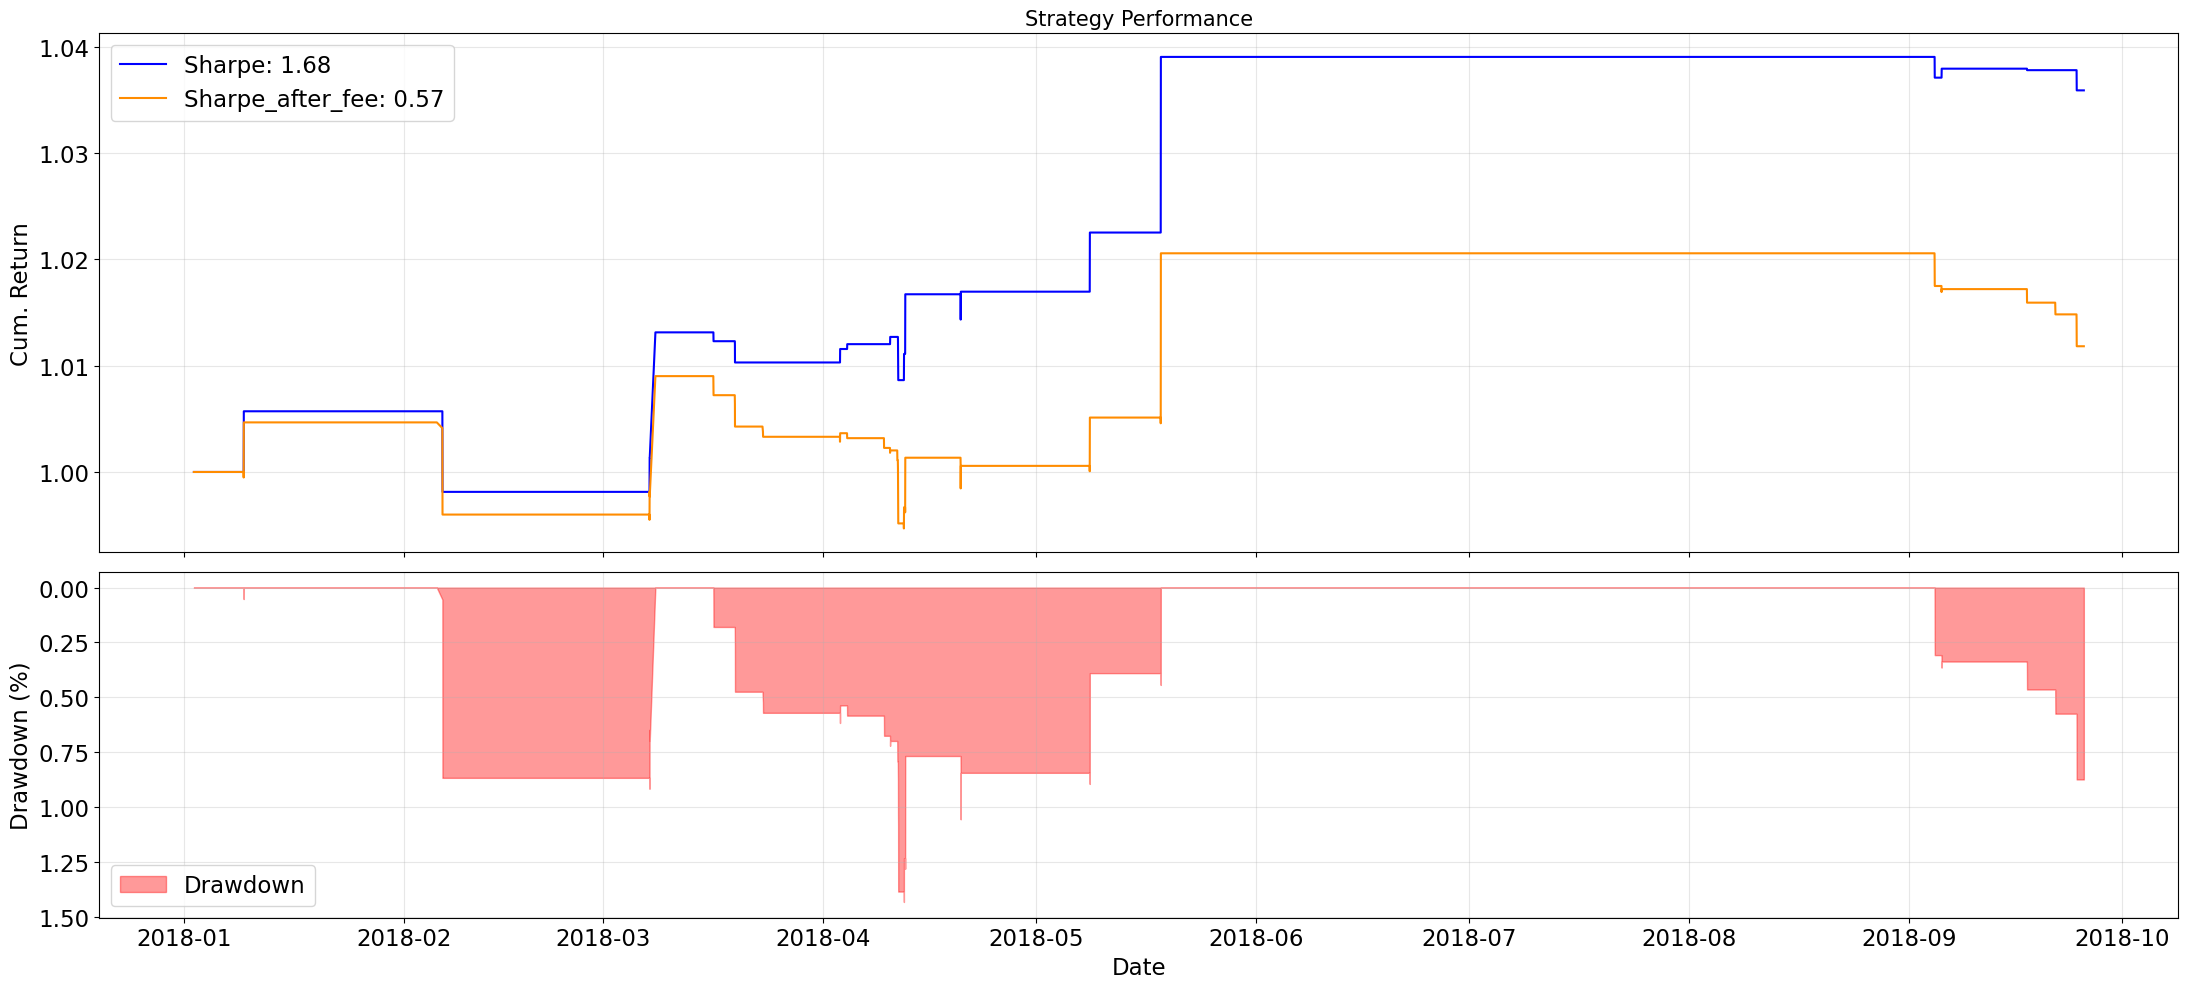

 
OUT SAMPLE PERFORMANCE

             Financial Backtest Vn Future
    Initial capital: 10,000.00
     Ending capital: 6,134.92
             Sharpe: -1.75
            Sortino: -0.91
             Calmar: -0.11
                MDD: 3,880.45 (38.80%); Time: 2018-10-11 09:30:00 -> 2024-12-25 11:00:00
       Total Profit: -3,865.08
   Margin per Trade: -5.48 bps
       Total Return: -25.64%
    Return per year: -4.13%
               CAGR: -4.66%
       Hitrate Long: 4.86%
      Hitrate Short: 2.81%
      Total Hitrate: 4.00%
        Longest Win: 2 days
       Longest Loss: 4 days
      Trade per Day: 0.23
        Long Trades: 203
       Short Trades: 150



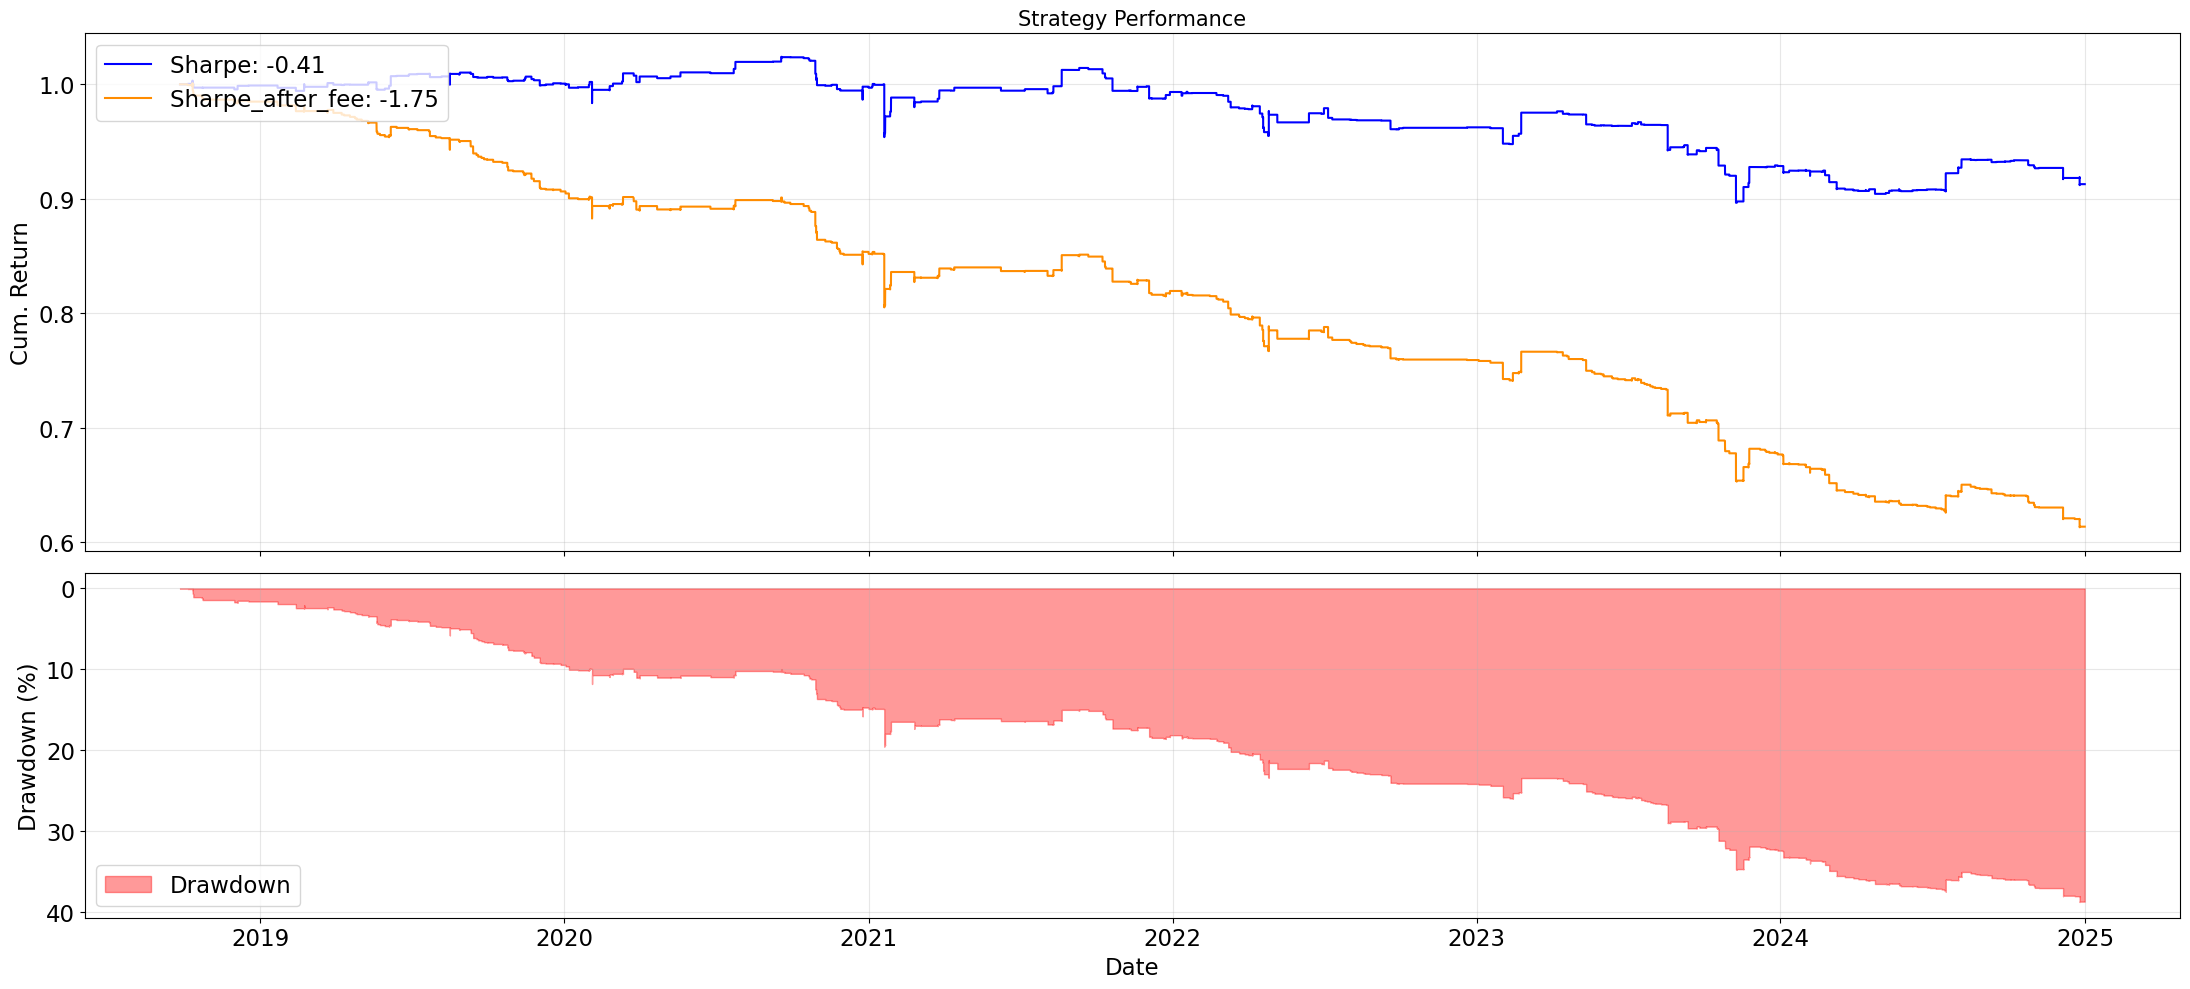

 
ALL DATA PERFORMANCE

             Financial Backtest Vn Future
    Initial capital: 10,000.00
     Ending capital: 6,251.72
             Sharpe: -1.55
            Sortino: -0.81
             Calmar: -0.09
                MDD: 3,959.35 (39.59%); Time: 2018-05-18 14:00:00 -> 2024-12-25 11:00:00
       Total Profit: -3,748.28
   Margin per Trade: -5.06 bps
       Total Return: -24.29%
    Return per year: -3.51%
               CAGR: -3.94%
       Hitrate Long: 4.55%
      Hitrate Short: 2.63%
      Total Hitrate: 3.74%
        Longest Win: 2 days
       Longest Loss: 4 days
      Trade per Day: 0.22
        Long Trades: 217
       Short Trades: 161



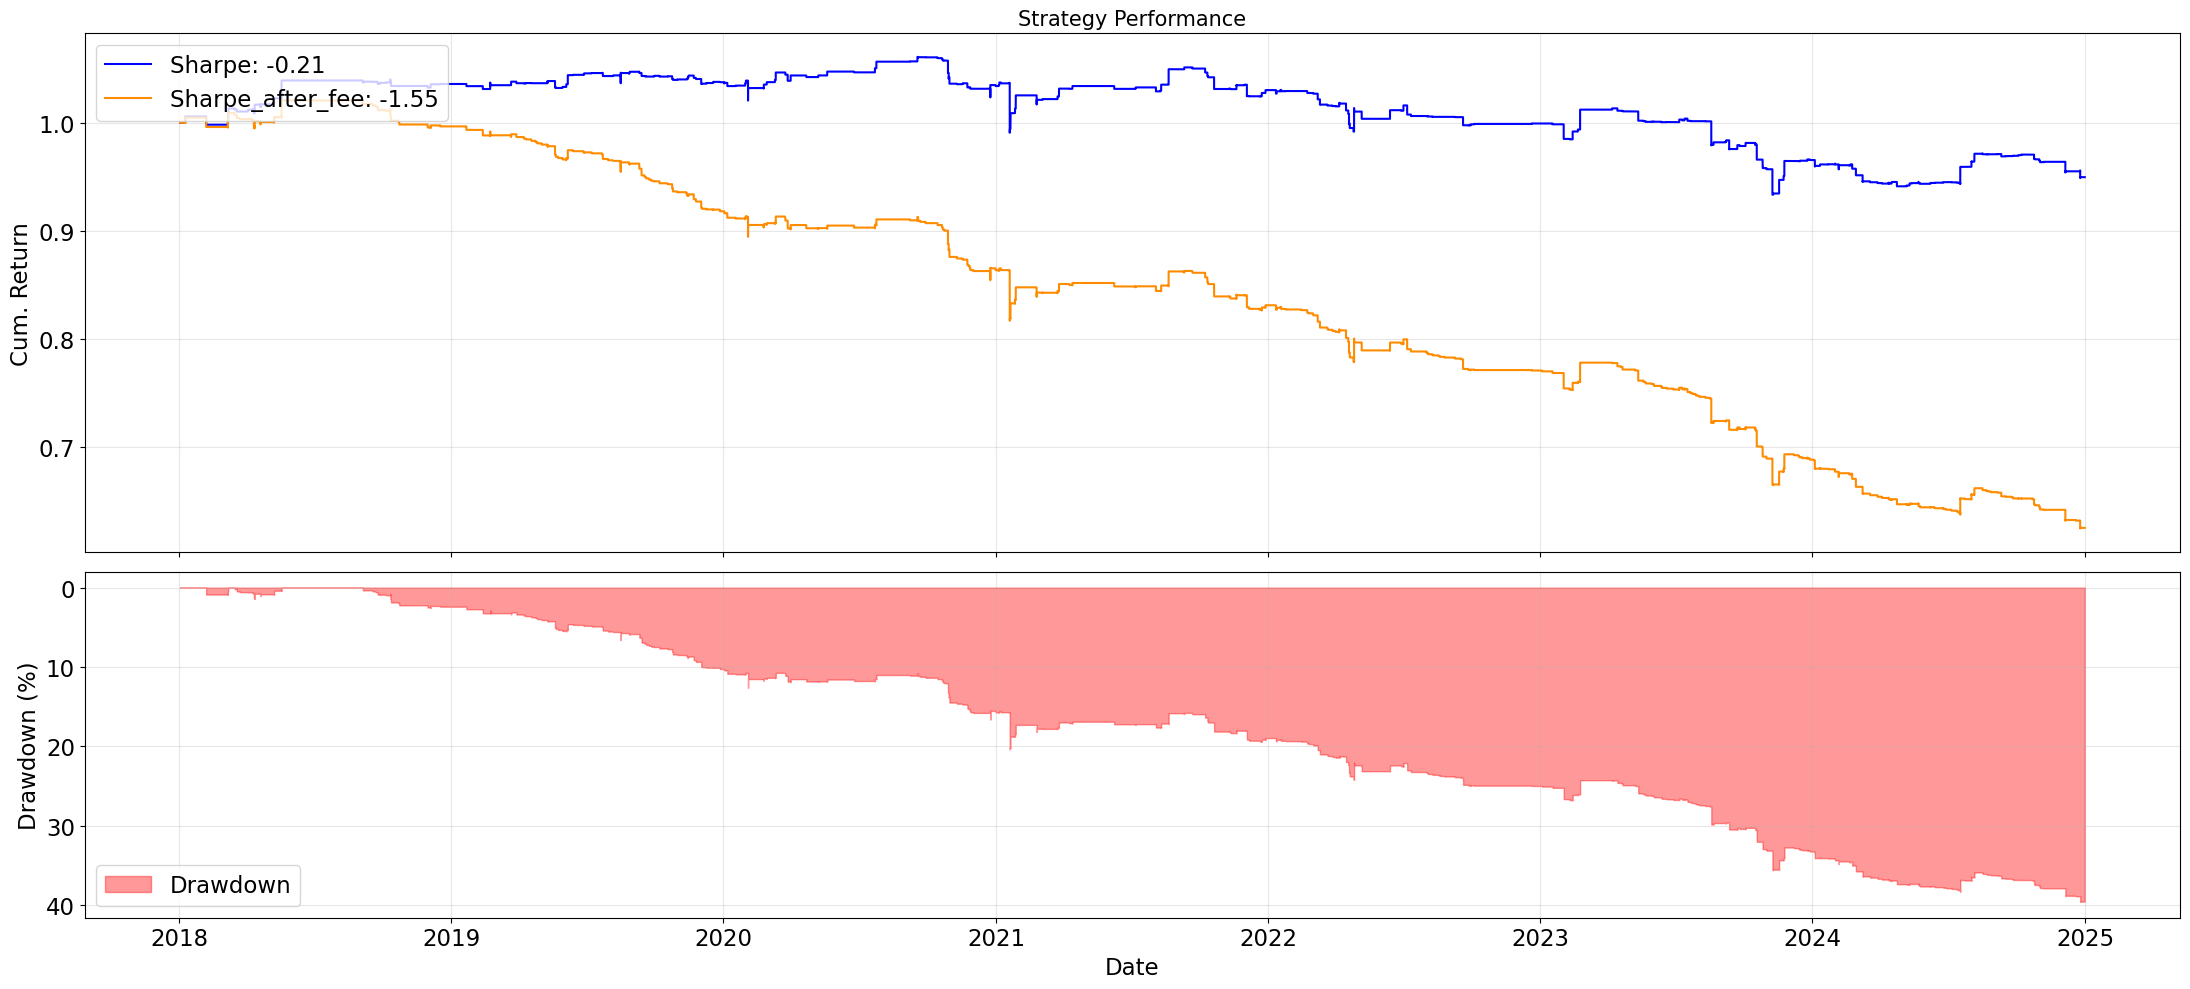

##########################################  
        TA Stat Backtest vn_future 
##########################################
Fail future leak test.

In [8]:
RED = "\033[31m"
RESET = "\033[0m"
print(f"{RED}AFTER OPTUNA PLEASE RUN CELL 1 AGAIN TO SEE RESULT AFTER OPTIMIZATION{RESET}")

alpha.backtest(vnmerge, oos_ratio=oos_ratio)